In [4]:
import pandas as pd

# Load and convert date
df_q3 = pd.read_csv(r'C:\Users\swaro\Downloads\q3_retail_promotions.csv')
df_q3['transaction_date'] = pd.to_datetime(df_q3['transaction_date'])

# Extract temporal features
df_q3['year'] = df_q3['transaction_date'].dt.year
df_q3['month'] = df_q3['transaction_date'].dt.month
df_q3['day_of_week'] = df_q3['transaction_date'].dt.dayofweek

# Feature: is_month_end (1 if day >= 25)
df_q3['is_month_end'] = (df_q3['transaction_date'].dt.day >= 25).astype(int)

# Display sample
df_q3[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].sample(5)

,transaction_date,year,month,day_of_week,is_month_end
209,2022-06-21,2022,6,1,0
1127,2024-10-27,2024,10,6,1
980,2024-07-02,2024,7,1,0
108,2022-03-28,2022,3,0,1
863,2024-03-25,2024,3,0,1


In [5]:
# Sort by date
df_q3 = df_q3.sort_values('transaction_date')

# Calculate split point
split_idx = int(len(df_q3) * 0.8)

train_df = df_q3.iloc[:split_idx]
test_df = df_q3.iloc[split_idx:]

X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_df['items_sold']
X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_df['items_sold']

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify columns
cat_features = ['promotion_type', 'location_type', 'store_size']
num_features = [col for col in X_train.columns if col not in cat_features]

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# Example of how the pipeline will be used later
# full_pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', model)])

Linear Regression -> RMSE: 27.12, MAE: 21.05


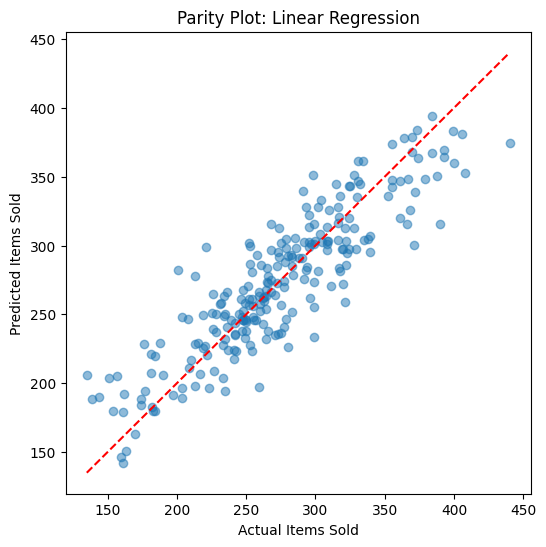

Random Forest -> RMSE: 30.84, MAE: 24.31


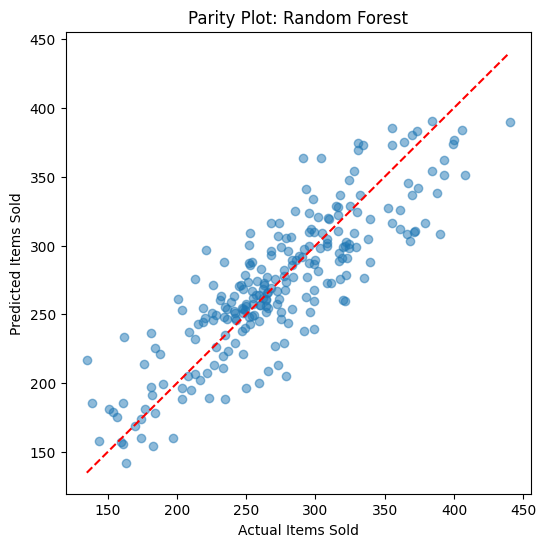


Top 5 Influential Features:
                Feature  Importance
2           is_festival    0.173413
18     store_size_small    0.166752
15  location_type_urban    0.108505
6           day_of_week    0.080552
1            is_weekend    0.067103


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Create and fit pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}")
    
    # Parity Plot
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'Parity Plot: {name}')
    plt.xlabel('Actual Items Sold')
    plt.ylabel('Predicted Items Sold')
    plt.show()

    if name == "Random Forest":
        # Feature Importances
        ohe_cols = pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_features)
        all_features = list(num_features) + list(ohe_cols)
        importances = pipeline.named_steps['regressor'].feature_importances_
        
        feat_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
        print("\nTop 5 Influential Features:")
        print(feat_df.sort_values(by='Importance', ascending=False).head(5))

Linear Regression -> RMSE: 27.12, MAE: 21.05


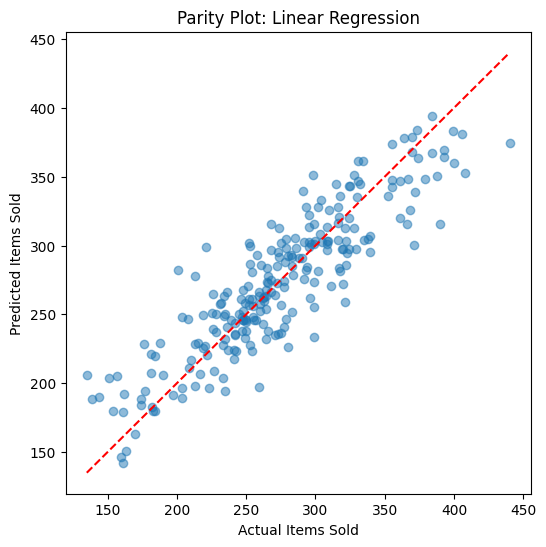

Random Forest -> RMSE: 30.84, MAE: 24.31


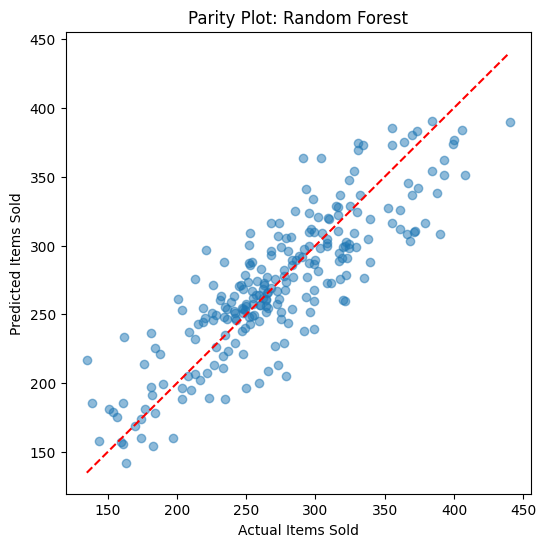


Top 5 Influential Features:
                Feature  Importance
2           is_festival    0.173413
18     store_size_small    0.166752
15  location_type_urban    0.108505
6           day_of_week    0.080552
1            is_weekend    0.067103


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Create and fit pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}")
    
    # Parity Plot
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'Parity Plot: {name}')
    plt.xlabel('Actual Items Sold')
    plt.ylabel('Predicted Items Sold')
    plt.show()

    if name == "Random Forest":
        # Feature Importances
        ohe_cols = pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_features)
        all_features = list(num_features) + list(ohe_cols)
        importances = pipeline.named_steps['regressor'].feature_importances_
        
        feat_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
        print("\nTop 5 Influential Features:")
        print(feat_df.sort_values(by='Importance', ascending=False).head(5))

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns # Optional, but good to have for styling